Name: **your name here**

In [44]:
# Show all output of one executed cell:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import matplotlib.pyplot as plt

# Wrap up day 2

Welcome back again.  
Yesterday you learned a number of model analysis aspects.

Specifically you looked at
- exchange reactions and identified their essentiality
- media components and how they influences growth of a model organism
- learned about essential metabolic model components
- learned about target metabolite fluxes and their relationship to biomass production by analysing production envelopes
- computed geometric FBA solutions and assessed their usability
- analysed runtimes of different FBA methods

Particularly the choice of the right FBA method should be target-driven:  
What do you want to achieve or find out?

1. Target yield? Go with <code>slim_optimise()</code>
2. One flux distribution? <code>optimise()</code> or <code>pfba()</code>
3. Loopless solution? <code>loopless_solution()</code>
4. Unique or close to unique solution? <code>gfba()</code>

Note that you rarely go with option 4. It takes simply too long and its validity is nowhere proven (after all it is quasi-unique with respect to a mathematical, but not necessarily biological property).  
Rather compute pFBA in conjunction with FVA to get better constrained, albeit not unique, solutions. 


---

# Today

Today, you have a self-assignment task. In order for you to progress, occasionally you will find results you can compare to and see whether things go right. 

Task 1: Cross-check the *E. coli* core model against a full model of *E. coli*  
Task 2: Find best KOs for constraining flux through the full model, which holds a high Ethanol, but low biomass yield.  
Task 3: Load, analyse and compare 10 gut microbial relevant bacterial models

## Task 1 E. coli models

Read in the E. coli core model from yesterday.  
Also load the large E. coli model "iJO1366" which is shipped with cobrapy.  
More details and analysis about this model here: https://www.ncbi.nlm.nih.gov/pmc/articles/PMC3261703/ 

In [45]:
## your code ##
## load packages
import cobra
from cobra.io import load_model

## load models
m_eco_core = load_model("textbook")
m_eco = load_model("iJO1366")

## save default media to separate variables
m_eco_core_media = m_eco_core.medium 
m_eco_media = m_eco.medium 
## --- ##

How much bigger is the large model compared to the core model with regards to genes and reactions?

>
> #### your answer
>


### Task 1.1 Media

Compare growth rates for both models (note two possible obj. biomass functions in the large model - test both).  
Check the media of both models (save the default media to extra variables if not already happened).  
Check the minimal media for both.

In [46]:
## your code ##
from cobra.medium import minimal_medium

## compare growth rates
print("Growth rates")
m_eco_core.slim_optimize()

m_eco.slim_optimize()
m_eco.objective = "BIOMASS_Ec_iJO1366_WT_53p95M"
m_eco.slim_optimize()
m_eco.objective = "BIOMASS_Ec_iJO1366_core_53p95M"

## compare media
print("Media")
len(m_eco_core_media)
len(m_eco_media)
#(m_eco_core_media)
#(m_eco_media)
print("Minimal Media")
len(minimal_medium(m_eco_core))
len(minimal_medium(m_eco))
#(minimal_medium(m_eco_core))
#(minimal_medium(m_eco))
## --- ##

Growth rates


0.8739215069684279

0.9823718127269633

0.9865144469529796

Media


7

25

Minimal Media


4

17

*Solution hints:*  
The length of the media components of the core model devided by the length of the full model is 0.28.  
After minimizing media (default values for function's attributes) it is ~0.235.

---

What do you make of this?  
Does this invalidate the core model?  
What might be the pros and cons of the one over the other?

>
> #### your answer
>

### Task 1.2 Model comparison

How many genes contained in the core model are also part of the large model?  
How many reactions?

In [47]:
## your code ##
## create lists of gene and reaction ids
eco_core_genes_ids = list()
eco_core_rxn_ids = list()
eco_full_genes_ids = list()
eco_full_rxn_ids = list()
## use e.g. list comprehension to get all ids into your gene and reaction lists for both models
[(eco_core_genes_ids.append(g.id)) for g in m_eco_core.genes];
[(eco_full_genes_ids.append(g.id)) for g in m_eco.genes];
[(eco_core_rxn_ids.append(g.id)) for g in m_eco_core.reactions];
[(eco_full_rxn_ids.append(g.id)) for g in m_eco.reactions];

## --- ##

In [48]:
## your code ##

## check the set differences and intersections for genes and reactions between these models
## genes
set(eco_core_genes_ids).difference(set(eco_full_genes_ids))
len(eco_core_genes_ids)-len( set(eco_core_genes_ids).intersection(set(eco_full_genes_ids)) )
## reactions
set(eco_core_rxn_ids).difference(set(eco_full_rxn_ids))
len(eco_core_rxn_ids)- len( set(eco_core_rxn_ids).intersection(set(eco_full_rxn_ids)) )

## --- ##

set()

0

{'ACALDt',
 'ACt2r',
 'AKGt2r',
 'ATPS4r',
 'Biomass_Ecoli_core',
 'CO2t',
 'CYTBD',
 'D_LACt2',
 'ETOHt2r',
 'FORt2',
 'FORti',
 'FRD7',
 'FRUpts2',
 'FUMt2_2',
 'GLCpts',
 'GLNabc',
 'GLUt2r',
 'H2Ot',
 'MALt2_2',
 'NADH16',
 'NH4t',
 'O2t',
 'PIt2r',
 'PYRt2',
 'SUCCt2_2',
 'SUCCt3',
 'THD2'}

27

>
> #### your answer here
>

---

## Task 2 Gene & Rxn essentiality

Since genes are comparable let us run gene essentiality analyses between the two models and compare.  
Compare gene KO analysis only for the genes present in both models.  

Consider genes as essential if after its KO the achievable growth rate is below 10% of the maximum possible growth rate.


In [49]:
## your code ##
## imports of single_gene_deletion and pandas 
from cobra.flux_analysis import single_gene_deletion as geneKO
import pandas as pd
m_eco_core.medium=m_eco_core_media
m_eco.medium=m_eco_media
m1_ko=geneKO(model = m_eco_core,gene_list=m_eco_core.genes)
m2_ko=geneKO(model = m_eco,gene_list=m_eco_core.genes)

## add a column to the pandas df with only the gene id (use apply and e.g. a lambda function for this)
m1_ko['gids'] = m1_ko['ids'].apply(lambda x: list(x)[0])
m2_ko['gids'] = m2_ko['ids'].apply(lambda x: list(x)[0])
## rename columns for growth and status
m1_ko=m1_ko.rename(columns={"growth": "m1_growth", "status": "m1_status"})
m2_ko=m2_ko.rename(columns={"growth": "m2_growth", "status": "m2_status"})
## add columns to the dfs on whether genes are essential for growth (cut off 10% of respective theoretical maximum)
m_all_ko = pd.merge(left=m1_ko, right=m2_ko, on='gids')
m_all_ko['m1_essential']=1
m_all_ko['m2_essential']=1
m_all_ko['m1_essential']=[(g<0.1*m_eco_core.slim_optimize()) for g in m_all_ko['m1_growth']]
m_all_ko['m2_essential']=[(g<0.1*m_eco_core.slim_optimize()) for g in m_all_ko['m2_growth']]

## Which genes are essential in one but not the other model?
incomp = m_all_ko.query('m1_essential != m2_essential')
## print the genes and affected reactions that are not compatible between the two models
[print("%s : %s: %s" % (m_eco_core.genes.get_by_id(g).id,
                        m_eco_core.genes.get_by_id(g).name,
                        m_eco_core.genes.get_by_id(g).reactions)) 
 for g in incomp['gids']];
## --- ##

b2926 : pgk: frozenset({<Reaction PGK at 0x7f23aedac110>})
b1779 : gapA: frozenset({<Reaction GAPD at 0x7f23ae81b950>})
s0001 : G_s0001: frozenset({<Reaction CO2t at 0x7f23ae991510>, <Reaction NH4t at 0x7f23aebd0250>, <Reaction H2Ot at 0x7f23ae7c4550>, <Reaction ACALDt at 0x7f23ae58b150>, <Reaction O2t at 0x7f23adfcb9d0>})
b1812 : pabB: frozenset({<Reaction GLUN at 0x7f23ae62a690>})
b2779 : eno: frozenset({<Reaction ENO at 0x7f23ae628450>})


In [50]:
incomp

,ids_x,m1_growth,m1_status,gids,ids_y,m2_growth,m2_status,m1_essential,m2_essential
21,{b2926},1.052521e-15,optimal,b2926,{b2926},8.560605e-01,optimal,True,False
58,{b1779},-1.893389e-16,optimal,b1779,{b1779},8.560605e-01,optimal,True,False
123,{s0001},2.111407e-01,optimal,s0001,{s0001},1.901030e-30,optimal,False,True
128,{b1812},8.739215e-01,optimal,b1812,{b1812},-1.405714e-12,optimal,False,True
131,{b2779},1.520862e-15,optimal,b2779,{b2779},9.049382e-01,optimal,True,False


Briefly interpret your results.

>
> #### your answer
>

### Task 2.1 Yield favorable KOs

In biotech applications, we commonly want the model organism to grow near optimal towards a target yield, or to switch between growth and target yield production.

**Tasks**
With the full model and "BIOMASS_Ec_iJO1366_WT_53p95M" as the objective function:
- Constrain ammonia influx to 5 units (We assume we are limited in this resource)
- Compute reaction essentiality towards biomass for the wild type (WT)
- Compute reaction essentiality towards ethanol, with at least 50% biomass yield

Save your results to variables.

**Note:** This process will take some time! Save your results in variables.

In [51]:
## your code ##
from cobra.flux_analysis import single_reaction_deletion as rxnKO
## compute single KO of genes for WT-Biomoass as objective function
m_eco.objective = 'BIOMASS_Ec_iJO1366_WT_53p95M'
#m_eco.reactions.BIOMASS_Ec_iJO1366_WT_53p95M.lower_bound=0
m_eco.exchanges.EX_nh4_e.lower_bound=-5
optBM = m_eco.slim_optimize();
#m_eco.summary()
#gKObiomass = geneKO(model=m_eco)
rKObiomass = rxnKO(model=m_eco)
#rKObiomass
## compute single KO of genes for EX_etoh_e as objective function
m_eco.objective = 'EX_etoh_e'
m_eco.reactions.BIOMASS_Ec_iJO1366_WT_53p95M.lower_bound=0.5*optBM
optEtoh = m_eco.slim_optimize();
#m_eco.summary()
#gKOEtoh = geneKO(model=m_eco)
rKOEtoh = rxnKO(model=m_eco)
## --- ##

You will have noticed that the computation takes considerable time.  Hence, saving the results in variables (also intermediate results) is generally a good idea before continueing in a separate notebook to speed up analysis and its required coding.

### Task 2.2 Reaction KO analysis

Now identify reaction KOs for which the *E. coli* model increases ethanol yields over biomass yields.

- plot ethanol yield over biomass yield
    - add grids and a diagonal to your plot
- Identify the reactions that improve ethanol yield over biomass yield
- print out a pandas query, where you
    - require a minimum biomass yield
    - higher relative ethanol yield than relative biomass yield (with respect to each theoretical maximum) 


,gids,growth_bm,rel_growth_bm,growth_etoh,rel_growth_etoh,ess_bm,ess_etoh
322,O2tex,0.242185,0.508893,8.882099,0.545113,False,False
1049,EX_o2_e,0.242185,0.508893,8.882099,0.545113,False,False
2096,ATPS4rpp,0.402629,0.846027,15.071726,0.924983,False,False
2346,O2tpp,0.242185,0.508893,8.882099,0.545113,False,False


<Axes: xlabel='rel_growth_bm', ylabel='rel_growth_etoh'>

Reaction identifier,O2tpp
Name,O2 transport via diffusion (periplasm)
Memory address,0x7f23ab406a10
Stoichiometry,o2_p <=> o2_c O2 O2 <=> O2 O2
GPR,s0001
Lower bound,-1000.0
Upper bound,1000.0


Reaction identifier,O2tex
Name,Oxygen transport via diffusion (extracellular to periplasm)
Memory address,0x7f23ad3ed550
Stoichiometry,o2_e <=> o2_p O2 O2 <=> O2 O2
GPR,b1377 or b0241 or b0929 or b2215
Lower bound,-1000.0
Upper bound,1000.0


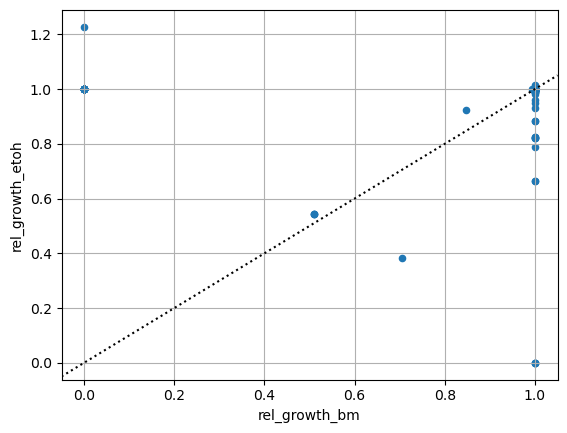

In [53]:
## your code ##
## add a relative growth column compared to optimum growth
rKObiomass['rel_growth']=rKObiomass['growth']/optBM
rKOEtoh['rel_growth']=rKOEtoh['growth']/optEtoh
## extract gene ids as strings and put to a new column (currently encapsulated in a 1-item set per row) 
rKObiomass['gids'] = rKObiomass['ids'].apply(lambda x: list(x)[0])
rKOEtoh['gids'] = rKOEtoh['ids'].apply(lambda x: list(x)[0])
## merge your dfs to one with the gene ids as merging variable ('on' attribute in pandas merge function)
rKO_all = pd.merge(rKObiomass[['gids', 'growth', 'rel_growth']], rKOEtoh[['gids', 'growth', 'rel_growth']], on='gids', 
                   suffixes=('_bm', '_etoh'))
rKO_all['ess_bm']=rKO_all['growth_bm']<=0.5*optBM
rKO_all['ess_etoh']=rKO_all['growth_etoh']<=0.5*optEtoh

## check which reactions hold a minimum relative biomass flux 
rKO_all.query('rel_growth_bm>0.1&rel_growth_bm<0.9&rel_growth_etoh>rel_growth_bm')

## plot relationship of relative growth values for Ethanol over biomass
rKO_all.plot(kind='scatter', x='rel_growth_bm',y='rel_growth_etoh', grid=True)
plt.axline((0, 0), slope=1, color="black", linestyle=':')

m_eco.reactions.O2tpp
m_eco.reactions.O2tex
## --- ##

Which reactions are affected?  
What appears the best modification of the biotechnological setup to improve ethanol production?  
What possibilities for model modifications exist
Interpret your results and put them into context of ressource efficiency and efforts towards model organism manipulation

>
> #### your answer
>

### Task 2.3 Screening gene KOs

- Identify the genes for the reactions O2tpp and O2tex (Hint: 4)
- perform a gene KO by using the function <code>knock_out_model_genes</code>
- simulate growth (biomass yield)

In [54]:
## your code ##

from cobra.manipulation.delete import knock_out_model_genes as koModelGenes
m_eco.medium=m_eco_media;
m_eco.slim_optimize()

## make a copy of the model; manipulate genes only on the copy
m_eco_mod = m_eco.copy()
#koModelGenes(model=m_eco_mod, gene_list='s0001')
rxnKO = koModelGenes(model=m_eco_mod, gene_list=['b1377', 'b0241', 'b0929', 'b2215']); 
## optimise
m_eco_mod.slim_optimize()

## --- ##

16.294062516519944

nan

What impact have the gene KOs?  
Interpret

>
> #### your answer
>

### Task 2.4 Aerob growth

Now, simulate aerob growth and compare ethanol and biomass yields.  
Compute Ethanol over biomass yield for both aerob and anaerob growth.

Use the WT biomass objective function.

In [55]:
## your code ##
## compute single KO of genes for WT-Biomoass as objective function
m_eco.objective = 'BIOMASS_Ec_iJO1366_WT_53p95M'
## modify the model to resemble restricted ammonia and forbidden O2 influx
m_eco.exchanges.EX_nh4_e.lower_bound=-5
m_eco.exchanges.EX_o2_e.lower_bound=0
optBMana = m_eco.slim_optimize();
m_eco.objective = 'EX_etoh_e'
m_eco.reactions.BIOMASS_Ec_iJO1366_WT_53p95M.lower_bound=0.5*optBMana
optEtohAna = m_eco.slim_optimize();

optEtohAna/optBMana
optEtoh/optBM

## --- ##

75.23759174141934

34.237993368400865

What is the better growth regime for ethanol production?  
What is the summary of your analysis and results?

>
> #### your answer
>

---

## Task 3 : Gut microbial models

Next, we will investigate 10 members of microbial models. 

- Download the models to your hard drive from the github workshop page
- Download the two given dietary descriptions (EU average and unhealthy) as well
 
**Note:** There were several landmarking papers on gut microbial models, allowing to simulate a number of gut bacterial species at the genome scale. Cf. https://www.nature.com/articles/s41587-022-01628-0 

**Note2:** All models and diets (and many more!) are available at https://www.vmh.life/  

- Load 10 models from vmh.life to your hard drive (5 Lactos, 5 others)
- Load two diets from the webpage (explain how)
- Find out shared reactions by the models
- Simulate growth on different diets and compare
- Run single Rxn KO over all models for shared reactions.
    - plot essential rxns, sort by frequency
    - which pathways are mostly affected?

### Task 3.1 E. coli model

- Start by loading the *E. coli* model from the collection
- Save the media definition that ships with this model into a variable
- Print out its model summary  
- Print an overview of the model's top20 subsystems (in terms of number of associated reactions)
    - plot a bar chart for this by e.g. creating a pandas data frame from the model's reactions dictlist and then using <code>df.value_counts()</code>

PosixPath('/home/schaeuble/Documents/teaching/2402_Norge_workshop/material/day3/microbes')

Name,Escherichia_coli_str_K_12_substr_MG1655
Memory address,7f2384ac8f10
Number of metabolites,1625
Number of reactions,2313
Number of genes,1205
Number of groups,78
Objective expression,1.0*biomass525 - 1.0*biomass525_reverse_5c178
Compartments,"Cytoplasm, Extracellular"


pandas.core.frame.DataFrame

<Axes: ylabel='subsystems'>

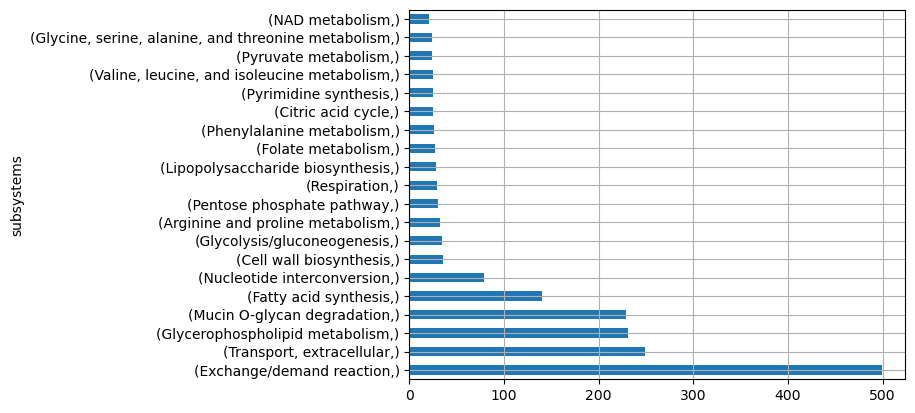

In [56]:
## your code ##
from cobra.io import read_sbml_model
from pathlib import Path
import pandas as pd 
PATH = Path(".") / ".." / "day3" / "microbes" 
PATH = PATH.resolve()
PATH

str_microbes= "Escherichia_coli_str_K_12_substr_MG1655.xml.gz"
m1 = read_sbml_model(str((PATH / str_microbes).resolve()) )
m1
m1_media = m1.medium 
df_eco = pd.DataFrame({ "subsystems" : [r.subsystem for r in m1.reactions] })
type(df_eco)
df_eco.value_counts().head(20).plot(kind="barh", grid=1)

## --- ##

**Note:** We did not have the metabolic subsystem information available before. In fact, it is a valuable property to run downstream analysis.

### Task 3.2 Adapt media

We have two media given by the web resource, EU average and unhealthy.
Let us investigate how E. coli deals with these media types.

#### Task 3.2.1 Load media and adapt media

- load into pandas data frames
- investigate id's of media reactions and compare to reactions as defined in the model
- make ids of exchange reactions compatible to your model
- adapt media and optimise model
    1. with original media definition (What is the growth rate?)
    2. only allow influx as given by the media
    3. optimise again

**Hints:** 
- use <code>pd.read_csv</code> to load the media
- use the panda dataframe's <code>replace()</code> function to modify id's
- you cannot copy the media directly to the model's medium definition
    - the type of model.medium is "dict", hence you need to provide a dictionary (transform the pandas df to a dictionary by using df.to_dict() functionality)
    - this may still throw an error if exchange reactions of a given media are not defined in a model
        - filter the media dictionary first using e.g. *dictionary comprehension* over the keys (e.g. <code>filtered_dict = {key: original_dict[key] for key in keys_to_filter if key in original_dict}</code>)
     
**Note:** You may be confused by flux ranges of media components. All given quantities are positive, however, we learned influx of exchange reactions is negative. Calling or replacing <code>model.medium</code> with the given media information works anyways, as internally the information are transformed to negative values for the lower bounds. You can check this out by calling the details of one specific reaction, e.g. <code>model.reactions.get_by_id('EX_so4(e)')</code>


In [57]:
## your code ##

len(m1_media)
## read in diets
diet_eu  = pd.read_csv(str((PATH / "diet_EUaverage_fluxes.tsv").resolve()), sep = '\t' )
diet_bad = pd.read_csv(str((PATH / "diet_unhealthy_fluxes.tsv").resolve()), sep = '\t' )
diet_eu.head()
## modify EX_rxn name to comply with model information
diet_eu = diet_eu.replace(to_replace='\[', value='(', regex=True)
diet_eu = diet_eu.replace(to_replace='\]', value=')', regex=True)
diet_bad = diet_bad.replace(to_replace='\[', value='(', regex=True)
diet_bad = diet_bad.replace(to_replace='\]', value=')', regex=True)
diet_eu.head()

#type(diet_eu_dict)
#type( m1.exchanges.list_attr('id'))

diet_eu_dict = diet_eu.set_index('Reaction')['Flux Value'].to_dict()
diet_eu_dict = {key: diet_eu_dict[key] for key in m1.exchanges.list_attr('id') if key in diet_eu_dict}
diet_bad_dict = diet_bad.set_index('Reaction')['Flux Value'].to_dict()
diet_bad_dict = {key: diet_bad_dict[key] for key in m1.exchanges.list_attr('id') if key in diet_bad_dict}

## adapting strictly media components 
print("Precise EU medium:")
m1.medium = diet_eu_dict
len(m1.medium)
m1.slim_optimize()
print("Precise unhealthy medium:")
m1.medium = diet_bad_dict
len(m1.medium)
m1.slim_optimize()

## --- ##

481

,Reaction,Flux Value
0,EX_etoh[e],234.434016
1,EX_h2o[e],165892.342500
2,EX_caro[e],0.003586
3,EX_retinol[e],3.002252
4,EX_thm[e],5.407858


,Reaction,Flux Value
0,EX_etoh(e),234.434016
1,EX_h2o(e),165892.342500
2,EX_caro(e),0.003586
3,EX_retinol(e),3.002252
4,EX_thm(e),5.407858


Precise EU medium:


51

0.0

Precise unhealthy medium:


51

0.0

*Solution hints:*  
The number of exchange reactions of the original media is 481.  
The length of both given media as well as the model defined medium (e.g. len(m.medium)) is 51.  

---

What do you observe?  
What might be the reason?

>
> #### your answer here
>

#### Task 3.2.2 Merge media into "open" media

Instead of using only the given components at the given quantities, we "merge" the given media information into the original medium definition (which is basically an open media).

- copy the original media back into the model.medium definition
- adapt media bounds for which we have information in the given media files (separately per media definition)
    - use e.g. dictionary comprehension again over the model's medium items (<code>model.medium.items()</code>)
- optimise
- get the minimal media, once for minimal flux (default setup) and once by also requiring minimal number of components instead of minimizing flux (check the functions attributes in e.g. the documentation)
    - set the min_objective_value to the optimal growth value after adapting the media 


In [58]:
## your code ##

## merging media in original "open" media
## EU average medium
print("Adapted EU medium:")
m1.medium = m1_media
m1.medium = {key: diet_eu_dict[key] if key in diet_eu_dict else value for key, value in m1.medium.items()}
m1.medium = minimal_medium(model = m1, min_objective_value=m1.slim_optimize())
m1.medium
print("m1.medium, flux:")
len(m1.medium)
m1.slim_optimize()
m1.medium = m1_media
m1.medium = {key: diet_eu_dict[key] if key in diet_eu_dict else value for key, value in m1.medium.items()}
m1.medium = minimal_medium(model = m1, min_objective_value=m1.slim_optimize(), minimize_components=1)
print("m1.medium, components:")
len(m1.medium)
m1.medium
min_media = {"EU" : m1.medium}
m1.slim_optimize()
## unheathly medium
print("Adapted unhealthy medium:")
m1.medium = m1_media
m1.medium = {key: diet_bad_dict[key] if key in diet_bad_dict else value for key, value in m1.medium.items()}
m1.medium = minimal_medium(model = m1, min_objective_value=m1.slim_optimize()) 
m1.medium
m1.slim_optimize()
m1.medium = m1_media
m1.medium = {key: diet_bad_dict[key] if key in diet_bad_dict else value for key, value in m1.medium.items()}
m1.medium = minimal_medium(model = m1, min_objective_value=m1.slim_optimize(), minimize_components=1) 
len(m1.medium)
m1.medium
min_media['bad'] = m1.medium
m1.slim_optimize()

## --- ##

Adapted EU medium:


{'EX_MGlcn196_rl(e)': 13.620118395084221,
 'EX_alahis(e)': 0.42312089925118496,
 'EX_alltn(e)': 0.1432545969005423,
 'EX_arg_L(e)': 1.3168766032965797,
 'EX_ca2(e)': 0.035674944134957885,
 'EX_cl(e)': 0.035674944134957885,
 'EX_cobalt2(e)': 0.035674944134957885,
 'EX_cu2(e)': 0.035674944134957885,
 'EX_cytd(e)': 1.3414261397246379,
 'EX_fe2(e)': 0.035674944134957885,
 'EX_fe3(e)': 0.03567494413495789,
 'EX_glyasn(e)': 1.0720664698429991,
 'EX_glycys(e)': 0.4778288148364297,
 'EX_glymet(e)': 0.7178907554795697,
 'EX_glytyr(e)': 1.4381167776174992,
 'EX_gsn(e)': 2.08931355988617,
 'EX_k(e)': 0.035674944134957885,
 'EX_mg2(e)': 0.035674944134957885,
 'EX_mn2(e)': 0.035674944134957885,
 'EX_nmn(e)': 5.347901348372346,
 'EX_so4(e)': 0.035674944134957885,
 'EX_trp_L(e)': 0.2519685114928,
 'EX_zn2(e)': 0.035674944134957885}

m1.medium, flux:


23

4.56820551322227

...

{'EX_MGlcn196_rl(e)': 11.24277259438098,
 'EX_alahis(e)': 0.39120485435797964,
 'EX_alltn(e)': 0.4699436728071677,
 'EX_arg_L(e)': 1.2175444907396091,
 'EX_ca2(e)': 0.03298398010886288,
 'EX_cgly(e)': 0.441786147285441,
 'EX_cl(e)': 0.03298398010886287,
 'EX_cobalt2(e)': 0.03298398010886287,
 'EX_cu2(e)': 0.03298398010886288,
 'EX_cytd(e)': 1.2402422535773479,
 'EX_fe2(e)': 0.03298398010886288,
 'EX_fe3(e)': 0.03298398010886289,
 'EX_glyasn(e)': 0.991200406170505,
 'EX_glymet(e)': 0.6637401956257506,
 'EX_glytyr(e)': 1.3296395085500965,
 'EX_gsn(e)': 1.9317164629543992,
 'EX_k(e)': 0.03298398010886288,
 'EX_mg2(e)': 0.03298398010886288,
 'EX_mn2(e)': 0.03298398010886288,
 'EX_nmn(e)': 4.94450870144619,
 'EX_so4(e)': 0.03298398010886288,
 'EX_trp_L(e)': 0.23296250555286577,
 'EX_zn2(e)': 0.03298398010886288}

4.223625388488635

12

{'EX_ca2(e)': 0.0329839801088975,
 'EX_cl(e)': 0.0329839801088975,
 'EX_cobalt2(e)': 0.0329839801088975,
 'EX_cu2(e)': 0.0329839801088975,
 'EX_fe2(e)': 0.065967960217795,
 'EX_k(e)': 0.0329839801088975,
 'EX_mg2(e)': 0.0329839801088975,
 'EX_mn2(e)': 0.0329839801088975,
 'EX_nmn(e)': 946.8176881256014,
 'EX_o2(e)': 286.15916559785865,
 'EX_so4(e)': 1.1385103230210802,
 'EX_zn2(e)': 0.0329839801088975}

4.223625388492382

*Solution hints*  
Your optimised objective function values should both be similar and between 4 and 5.  
The minimal number of components should count 12 for both diets.

---

Do you observe similarities or differences in the minimal media? If so on what level?
Does this change for minimal media with minimal flux vs. minimal number of components?  
What might this mean for the organism at hand, despite the fact that there might be many variations for a minimum media that holds the maximum growth rate?

>
> ### your answer
>


### Task 3.3 FVA for four subsystem

- Run FVA for all reactions of the following subsystems:
    - Citric acid cycle
    - Fatty acid synthesis
    - Glycolysis/gluconeogenesis
    - NAD metabolism
        - run once per diet, given minimal diet of 12 components
        - use <code>pfba_factor=1.1</code>, <code>fraction_of_optimum=0.9</code> when running FVA as additional constraints
- track the results and count reaction fluxes as changed if either lower or upper bound changed by at least 5%

**Hints:**  
Use a pandas data frame to track the FVA values.  
The index of the FVA output dataframe might need to be reseted in order to be added to the pad

In [59]:
## your code ##
from cobra.flux_analysis import flux_variability_analysis as fva 

rxnIds = [r.id for r in m1.reactions if r.subsystem in 
                                  ['NAD metabolism', 'Citric acid cycle', 'Glycolysis/gluconeogenesis', 'Fatty acid synthesis']]
len(rxnIds)
fluxes = pd.DataFrame(data={ 'sub' : [r.subsystem for r in m1.reactions if r.id in rxnIds]}, 
                      index=rxnIds
                     )
fluxes

## FVA for EU medium
m1.medium = min_media['EU']
#m1.medium
m1.slim_optimize()
tmp = fva(m1, reaction_list=rxnIds, pfba_factor=1.1, fraction_of_optimum=0.9)
tmp
fluxes['eu_lb'] = tmp['minimum']
fluxes['eu_ub'] = tmp['maximum']
## FVA for unhealthy medium
m1.medium = min_media['bad']
#m1.medium
m1.slim_optimize()
tmp = fva(m1, reaction_list=rxnIds, pfba_factor=1.1, fraction_of_optimum=0.9)
fluxes['bad_lb'] = tmp['minimum']
fluxes['bad_ub'] = tmp['maximum']

fluxes

## --- ##

220

,sub
3CARLPDH,Citric acid cycle
3HAD100,Fatty acid synthesis
3HAD10M11,Fatty acid synthesis
3HAD10M12,Fatty acid synthesis
3HAD11M12,Fatty acid synthesis
...,...
THD1,NAD metabolism
THD2,NAD metabolism
TPI,Glycolysis/gluconeogenesis
r0163c,Citric acid cycle


4.5682055132222645

,minimum,maximum
3CARLPDH,0.000000,0.000000e+00
3HAD100,0.000000,1.820390e+00
3HAD10M11,0.000000,-1.142709e-14
3HAD10M12,0.000000,-3.126049e-15
3HAD11M12,0.000000,-4.236028e-15
...,...,...
THD1,-100.197575,6.237810e+01
THD2,0.000000,6.404196e+01
TPI,-15.032595,3.473497e+01
r0163c,0.000000,0.000000e+00


4.223625388492382

,sub,eu_lb,eu_ub,bad_lb,bad_ub
3CARLPDH,Citric acid cycle,0.000000,0.000000e+00,0.000000,0.000000e+00
3HAD100,Fatty acid synthesis,0.000000,1.820390e+00,0.000000,1.683078e+00
3HAD10M11,Fatty acid synthesis,0.000000,-1.142709e-14,0.000000,-1.330193e-14
3HAD10M12,Fatty acid synthesis,0.000000,-3.126049e-15,0.000000,-8.395593e-15
3HAD11M12,Fatty acid synthesis,0.000000,-4.236028e-15,0.000000,1.138872e-14
...,...,...,...,...,...
THD1,NAD metabolism,-100.197575,6.237810e+01,-92.639663,5.767291e+01
THD2,NAD metabolism,0.000000,6.404196e+01,0.000000,5.921127e+01
TPI,Glycolysis/gluconeogenesis,-15.032595,3.473497e+01,-13.898685,3.211491e+01
r0163c,Citric acid cycle,0.000000,0.000000e+00,0.000000,0.000000e+00


#### Task 3.3.1 Visualise the change in flux ranges

- Extend your data frame by adding a column that is True (or 1) if the change in lower bounds or upper bounds of the investigated reactions is at least 5%
- Use this data frame to create a new data frame with summary information per investigated subsystem
    - How many reactions changed flux in lower or upper bound?
    - Total number of reactions per subsystem
- Group over the subsystems and plot the number of changed reactions and the total number of reactions per subsystem as stacked bar plot (remember, that pandas data frames have a <code>df.plot()</code> function)

178

,Change
sub,
Citric acid cycle,22
Fatty acid synthesis,109
Glycolysis/gluconeogenesis,28
NAD metabolism,19


sub
Fatty acid synthesis          140
Glycolysis/gluconeogenesis     34
Citric acid cycle              25
NAD metabolism                 21
Name: count, dtype: int64

<Axes: xlabel='sub'>

<Axes: xlabel='sub'>

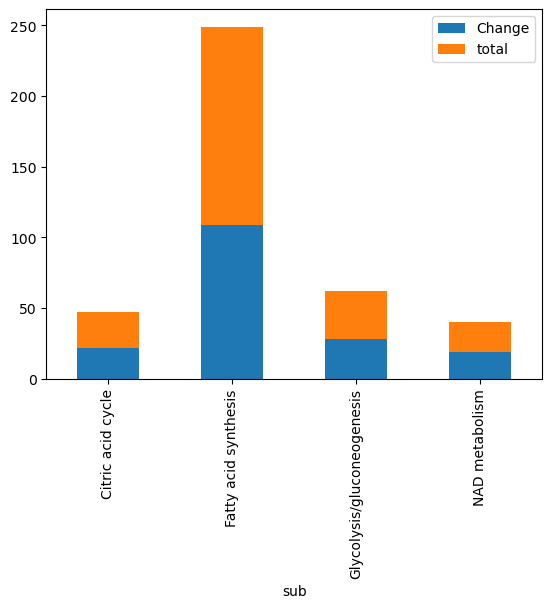

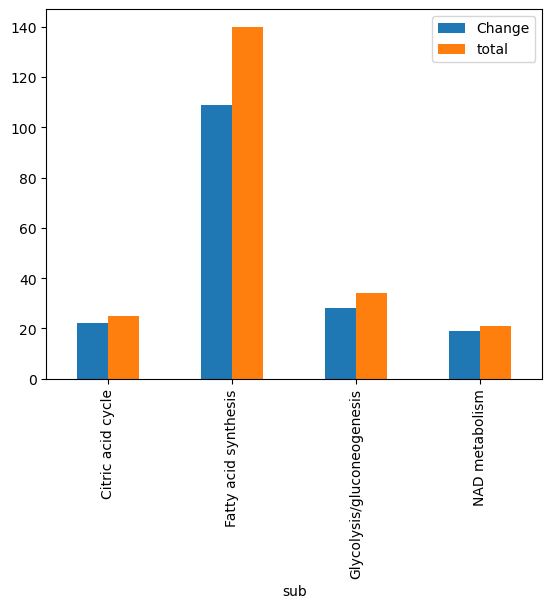

In [61]:
## your code ##
OFFSET = .05
#OFFSET
#fluxes['Change'] = (fluxes['eu_lb'] < fluxes['badlb']).astype(int)
fluxes['Change'] = ( 
    ((fluxes['eu_lb'] / fluxes['bad_lb']) > 1+OFFSET) |
    ((fluxes['eu_lb'] / fluxes['bad_lb']) < 1-OFFSET) |
    ((fluxes['eu_ub'] / fluxes['bad_ub']) > 1+OFFSET) |
    ((fluxes['eu_ub'] / fluxes['bad_ub']) < 1-OFFSET)
    )
#fluxes
sum(fluxes['Change'])
category_counts = fluxes.groupby('sub')['Change'].sum()

fluxes_summary = pd.DataFrame(data=category_counts)
fluxes_summary
fluxes['sub'].value_counts() 
fluxes_summary['total'] = fluxes['sub'].value_counts() 
fluxes_summary.plot(kind='bar', stacked=True)
fluxes_summary.plot(kind='bar', stacked=False)

## --- ##

What do you make out of these results?  
Why did we use FVA and not e.g. FBA?  

>
> #### your answer
>

### Task 3.4 Analysis of 10 gut GEMs

- Load all 10 models into a list or dictionary
- deep copy your models into another data structure (one list or dictionary per diet)
- create pandas data frames holding the models, diet and model specific minimal media and growth rates 
- Adapt for each model its media by using the knowledge we acquired above (changing only exchange reactions for which we know media constraints
    - derive also the minimum medium based on minmal flux and add the length to another data frame column
- finally, plot the log2 of fold change of biomass yield on EU vs unhealthy diet (log2(EU/unhealthy))

**Hints:** 
- log2 is a function of numpy
- this task will take considerable ressources from your local machine. Better save intermediate results into variables and keep working on them in independent notebook

In [62]:
## your code ##
from os import listdir
## load models and save into a list variable (load within list comprehension)
PATH
modelFiles = [f for f in listdir(PATH) if f.endswith('gz')]
modelFiles
models_eu  = [(read_sbml_model( str((PATH / f).resolve())  )) for f in modelFiles]
#models_bad  = [(read_sbml_model( str((PATH / f).resolve())  )) for f in modelFiles]
## make a copy of the created model list for the second diet 
#models_bad = models_eu.copy()
models_bad = [m.copy() for m in models_eu]
models_eu
models_bad
## --- ##

PosixPath('/home/schaeuble/Documents/teaching/2402_Norge_workshop/material/day3/microbes')

['Lactobacillus_rhamnosus_GG_ATCC_53103.xml.gz',
 'Alistipes_putredinis_DSM_17216.xml.gz',
 'Escherichia_coli_str_K_12_substr_MG1655.xml.gz',
 'Alistipes_finegoldii_DSM_17242.xml.gz',
 'Bacteroides_faecis_MAJ27.xml.gz',
 'Bacteroides_finegoldii_DSM_17565.xml.gz',
 'Lactobacillus_casei_ATCC_334.xml.gz',
 'Lactobacillus_buchneri_ATCC_11577.xml.gz',
 'Lactobacillus_fermentum_ATCC_14931.xml.gz',
 'Lactobacillus_reuteri_SD2112_ATCC_55730.xml.gz']

[<Model Lactobacillus_rhamnosus_GG_ATCC_53103 at 0x7f23d58ce390>,
 <Model Alistipes_putredinis_DSM_17216 at 0x7f239e33b950>,
 <Model Escherichia_coli_str_K_12_substr_MG1655 at 0x7f23b42d96d0>,
 <Model Alistipes_finegoldii_DSM_17242 at 0x7f23a1c2ee10>,
 <Model Bacteroides_faecis_MAJ27 at 0x7f23a0e74d50>,
 <Model Bacteroides_finegoldii_DSM_17565 at 0x7f239eb18290>,
 <Model Lactobacillus_casei_ATCC_334 at 0x7f236e401f90>,
 <Model Lactobacillus_buchneri_ATCC_11577 at 0x7f236eadbe50>,
 <Model Lactobacillus_fermentum_ATCC_14931 at 0x7f236e5b80d0>,
 <Model Lactobacillus_reuteri_SD2112_ATCC_55730 at 0x7f236cb8c310>]

[<Model Lactobacillus_rhamnosus_GG_ATCC_53103 at 0x7f23d602e450>,
 <Model Alistipes_putredinis_DSM_17216 at 0x7f235f6130d0>,
 <Model Escherichia_coli_str_K_12_substr_MG1655 at 0x7f235f068c10>,
 <Model Alistipes_finegoldii_DSM_17242 at 0x7f235e8b08d0>,
 <Model Bacteroides_faecis_MAJ27 at 0x7f235dde3a10>,
 <Model Bacteroides_finegoldii_DSM_17565 at 0x7f235cba3fd0>,
 <Model Lactobacillus_casei_ATCC_334 at 0x7f239df0ded0>,
 <Model Lactobacillus_buchneri_ATCC_11577 at 0x7f235b517690>,
 <Model Lactobacillus_fermentum_ATCC_14931 at 0x7f239df03590>,
 <Model Lactobacillus_reuteri_SD2112_ATCC_55730 at 0x7f239df03490>]

In [63]:
## your code ##
## create two pandas data frames holding the models
index = ['Lrh', 'Apu', 'Eco', 'Afi', 'Bfa', 'Bfi', 'Lca', 'Lbu', 'Lfe', 'Lre']
df_10_eu  = pd.DataFrame({ 'model' : models_eu}, index=index)
df_10_bad = pd.DataFrame({ 'model' : models_bad}, index=index)

## adapt the media to EU average and unhealthy, respectively, as we have done above for the E coli model
## add another column with the growth rate and minimal media size
for index, row in df_10_eu.iterrows():
    row['model'].medium = {key: diet_eu_dict[key] if key in diet_eu_dict else value for key, value in row['model'].medium.items()}
    row['model'].medium = minimal_medium(model=row['model'],min_objective_value=row['model'].slim_optimize() )
    df_10_eu.at[index, 'growth'] = row['model'].slim_optimize()
    df_10_eu.at[index, 'mediumSize'] = len(row['model'].medium)
df_10_eu
for index, row in df_10_bad.iterrows():
    row['model'].medium = {key: diet_bad_dict[key] if key in diet_bad_dict else value for key, value in row['model'].medium.items()}
    row['model'].medium = minimal_medium(model=row['model'],min_objective_value=row['model'].slim_optimize() )
    df_10_bad.at[index, 'growth'] = row['model'].slim_optimize()
    df_10_bad.at[index, 'mediumSize'] = len(row['model'].medium)
df_10_bad

## --- ##

,model,growth,mediumSize
Lrh,Lactobacillus_rhamnosus_GG_ATCC_53103,0.803892,35.0
Apu,Alistipes_putredinis_DSM_17216,4.128808,45.0
Eco,Escherichia_coli_str_K_12_substr_MG1655,4.568206,23.0
Afi,Alistipes_finegoldii_DSM_17242,11.521054,45.0
Bfa,Bacteroides_faecis_MAJ27,11.521054,36.0
Bfi,Bacteroides_finegoldii_DSM_17565,4.568206,21.0
Lca,Lactobacillus_casei_ATCC_334,0.411102,29.0
Lbu,Lactobacillus_buchneri_ATCC_11577,1.637111,24.0
Lfe,Lactobacillus_fermentum_ATCC_14931,4.568206,35.0
Lre,Lactobacillus_reuteri_SD2112_ATCC_55730,0.817305,36.0


,model,growth,mediumSize
Lrh,Lactobacillus_rhamnosus_GG_ATCC_53103,1.007112,35.0
Apu,Alistipes_putredinis_DSM_17216,4.736290,45.0
Eco,Escherichia_coli_str_K_12_substr_MG1655,4.223625,23.0
Afi,Alistipes_finegoldii_DSM_17242,10.652020,45.0
Bfa,Bacteroides_faecis_MAJ27,10.652020,36.0
Bfi,Bacteroides_finegoldii_DSM_17565,4.223625,21.0
Lca,Lactobacillus_casei_ATCC_334,0.515026,29.0
Lbu,Lactobacillus_buchneri_ATCC_11577,1.877983,24.0
Lfe,Lactobacillus_fermentum_ATCC_14931,4.223625,35.0
Lre,Lactobacillus_reuteri_SD2112_ATCC_55730,1.023916,36.0


,growth_eu,growth_bad,change
Lrh,0.803892,1.007112,-0.325150
Apu,4.128808,4.736290,-0.198032
Eco,4.568206,4.223625,0.113146
Afi,11.521054,10.652020,0.113146
Bfa,11.521054,10.652020,0.113146
Bfi,4.568206,4.223625,0.113146
Lca,0.411102,0.515026,-0.325150
Lbu,1.637111,1.877983,-0.198032
Lfe,4.568206,4.223625,0.113146
Lre,0.817305,1.023916,-0.325150


<Axes: ylabel='log2(growth change)'>

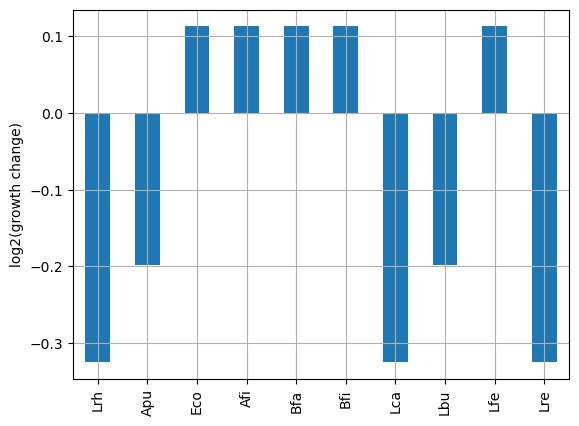

In [64]:
## your code ##
## import numpy
import numpy as np
## merge growth rates for both diets and compute the log2 of fold change from EU average to an unhealthy diet
df_grRates = pd.merge(left=df_10_eu['growth'], right=df_10_bad['growth'], left_index=True, right_index=True,
                      suffixes=('_eu', '_bad'))
df_grRates['change'] = np.log2(df_grRates['growth_eu']/df_grRates['growth_bad'])
df_grRates
## plot
df_grRates['change'].plot(kind="bar", grid=1, ylabel='log2(growth change)')

## --- ##

Interpret your results.
Is there any species that copes well (or not) with a change of diet?

>
> #### your answer
>

#### Task 3.4.1 FVA

- Loop over all models and compute the FVA for NAD metabolism and glycolysis
    - for both diets
- derive for each reaction per model, whether either lower or upper bound changed by at least 20% when switching the diet
- track your results in a pandas data frame

In [65]:
## your code ##

OFFSET=0.2

subNames = ['NAD metabolism', 'Glycolysis/gluconeogenesis']
## get all rxn IDs over all models associated to these pathways
## you can use rxn IDs as pandas index; Note that not all models have all reactions
## use set or dict comprehension again to track rxnIDs and reaction associated pathways
rxnIDs = set()
subs = dict()

for m in models_eu:
    rxnIDs.update({ (r.id) for r in m.reactions if r.subsystem in subNames})
    subs.update({ r.id: (r.subsystem) for r in m.reactions if r.subsystem in subNames if r.id not in subs})
#rxnIDs
#list(rxnIDs)

## create data frame from reaction ID set
models_df = pd.DataFrame({'model_eu' : df_10_eu['model'],
                       'model_bad' : df_10_bad['model']
                       })
gutFVA = pd.DataFrame({'rxnID' : list(rxnIDs),
                       }, index=list(rxnIDs))
#gutFVA

for index, row in models_df.iterrows():
    tpmIds = [r for r in rxnIDs if r in row['model_eu'].reactions] 
    tmp1 = fva(model=row['model_eu'], reaction_list=list(tpmIds), fraction_of_optimum=0.9, pfba_factor=1.1)
    tmp2 = fva(model=row['model_bad'],reaction_list=list(tpmIds), fraction_of_optimum=0.9, pfba_factor=1.1)

#    gutFVA[index+'_obj_eu']=row['model_eu'].slim_optimize()
#    gutFVA[index+'_obj_bad']=row['model_bad'].slim_optimize()
    #gutFVA[index+'_lb']=(tmp1['minimum'] / tmp2['minimum'])
    #gutFVA[index+'_ub']=(tmp1['maximum'] / tmp2['maximum'])
       
    foo = ((tmp1['minimum'] / tmp2['minimum'] > 1+OFFSET) |
           (tmp1['minimum'] / tmp2['minimum'] < 1-OFFSET) |
           (tmp1['maximum'] / tmp2['maximum'] > 1+OFFSET) | 
           (tmp1['maximum'] / tmp2['maximum'] < 1-OFFSET)
          )
    
    gutFVA[index+'_ess']=foo

## --- ##

#### Task 3.4.2 Vizualise overall change

- summarize your information in an extra pandas dataframe
- plot the total number of reactions belonging to either subsystem and the number of reactions changed at least once over all models

,rxnID,Lrh_ess,Apu_ess,Eco_ess,Afi_ess,Bfa_ess,Bfi_ess,Lca_ess,Lbu_ess,Lfe_ess,Lre_ess
FRUK,FRUK,True,NaN,False,False,False,NaN,False,NaN,NaN,NaN
NT5C,NT5C,NaN,NaN,False,False,False,False,NaN,NaN,NaN,True
PPS,PPS,NaN,NaN,False,False,False,NaN,NaN,NaN,NaN,True
NADN,NADN,NaN,NaN,NaN,False,False,NaN,NaN,NaN,NaN,NaN
PYK,PYK,True,False,True,False,False,False,True,False,False,True


,sub,numEss,freq
TPI,Glycolysis/gluconeogenesis,5,0.5
PDHbr,Glycolysis/gluconeogenesis,5,0.5
PYK,Glycolysis/gluconeogenesis,4,0.4
PGMT2,Glycolysis/gluconeogenesis,4,0.4
LDH_L,Glycolysis/gluconeogenesis,4,0.4
...,...,...,...
NMNAT,NAD metabolism,0,0.0
6PHBG2,Glycolysis/gluconeogenesis,0,0.0
NADN,NAD metabolism,0,0.0
G1PP,Glycolysis/gluconeogenesis,0,0.0


,total,sumFreq,numRxnsChanged
sub,,,
Glycolysis/gluconeogenesis,40,8.7,27
NAD metabolism,22,3.1,15


<Axes: >

<Axes: title={'center': 'Summary'}, xlabel='sub'>

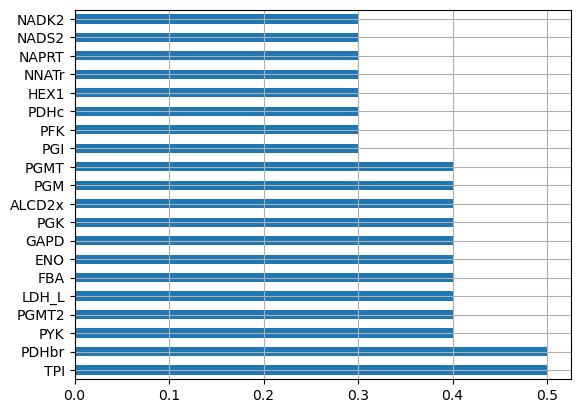

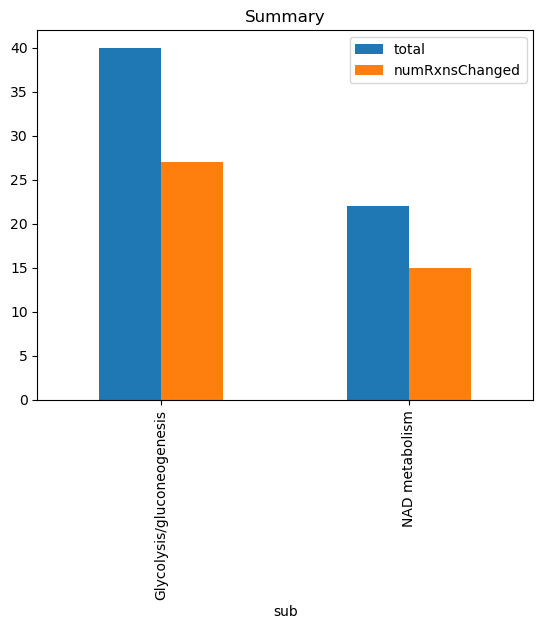

In [66]:
## your code ##
#subs
gutFVA.head()
#rxnIDs

## create data frame
gutFVA_freq_df = pd.DataFrame({
    'sub' : subs,
    'numEss' : gutFVA.drop('rxnID', axis=1).sum(axis=1)})

gutFVA_freq_df['freq'] = gutFVA_freq_df['numEss']/10
gutFVA_freq_df = gutFVA_freq_df.sort_values(by = 'freq', ascending=0)
#gutFVA_freq_df['changed'] = gutFVA_freq_df['numEss']>0
gutFVA_freq_df
subsSummary= pd.DataFrame({
    'total': gutFVA_freq_df.groupby('sub').size(),
    'sumFreq': gutFVA_freq_df.groupby('sub')['freq'].sum(),
    #'numRxnsChanged': gutFVA_freq_df.groupby('sub')['changed'].sum(),
    'numRxnsChanged': gutFVA_freq_df[gutFVA_freq_df['numEss']>0].groupby('sub').size()
    
})
subsSummary

## output plots (e.g. df.plot(kind = 'bar'))
gutFVA_freq_df['freq'].head(20).plot(kind='barh', grid=1)
subsSummary.drop('sumFreq', axis=1).plot(kind='bar', title='Summary')

## --- ##

#### Task 3.4.3 Vizualise change per species

- summarize your information in an extra pandas dataframe
- plot the total number of reactions belonging to either subsystem and the number of reactions changed at least once over all models

,Lrh_ess,Apu_ess,Eco_ess,Afi_ess,Bfa_ess,Bfi_ess,Lca_ess,Lbu_ess,Lfe_ess,Lre_ess
sub,,,,,,,,,,
Glycolysis/gluconeogenesis,26,0,10,1,1,1,24,2,0,22
NAD metabolism,7,0,5,0,1,0,7,0,0,11


sub
Glycolysis/gluconeogenesis    40
NAD metabolism                22
dtype: int64

,Lrh_ess,Apu_ess,Eco_ess,Afi_ess,Bfa_ess,Bfi_ess,Lca_ess,Lbu_ess,Lfe_ess,Lre_ess
sub,,,,,,,,,,
Glycolysis/gluconeogenesis,0.65,0.0,0.25,0.025,0.025,0.025,0.6,0.05,0.0,0.55
NAD metabolism,0.318182,0.0,0.227273,0.0,0.045455,0.0,0.318182,0.0,0.0,0.5


<Axes: xlabel='#Rxns with diet dep. flux change', ylabel='Subsystem'>

<Axes: xlabel='Fraction of rxns with diet dep. flux change', ylabel='Subsystem'>

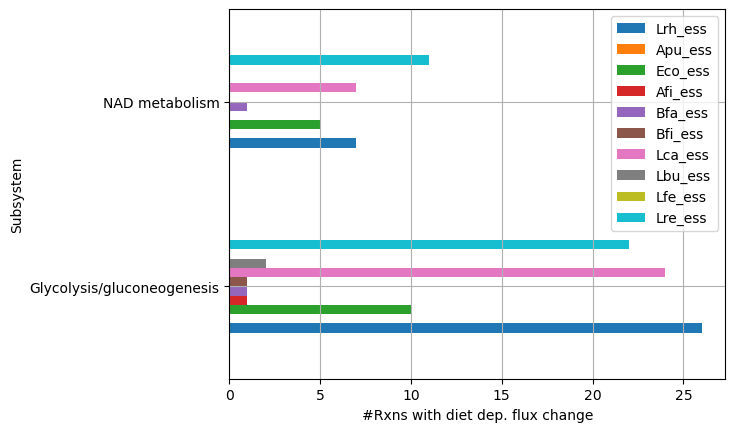

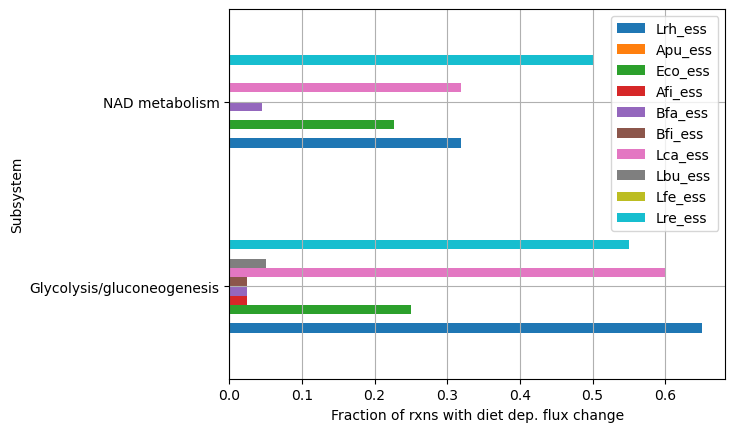

In [68]:
## your code ##
## create summary pandas data frame
gut10_summary = pd.DataFrame({
    'sub' : subs})
gut10_summary = pd.merge(gut10_summary, gutFVA.drop('rxnID', axis=1), left_index=True, right_index=True)
#gut10_summary
## df.groupby statistics
gut10_summary.groupby('sub').sum()
gut10_summary.groupby('sub').size()
gut10_summary.groupby('sub').sum().div(gut10_summary.groupby('sub').size(), axis=0)

## plot total number and fraction in individual plots
gut10_summary.groupby('sub').sum().plot(kind='barh', grid=1, ylabel='Subsystem', xlabel='#Rxns with diet dep. flux change')
gut10_summary.groupby('sub').sum().div(gut10_summary.groupby('sub').size(), axis=0).plot(
    kind='barh', grid=1, ylabel='Subsystem', xlabel='Fraction of rxns with diet dep. flux change')

## --- ##

Interpret your results briefly also in context with respective biomass yield changes.    
>
> #### your answer
>

### Task 3.5 (OPTIONAL)

Repeat 3.4.1 to 3.4.3 over all subsystems of the investigated species and plot the fraction of changed reactions per subsystem per species.

Since a bar plot will get messy, try using a heatmap instead (using e.g. the seaborn package)

Note that we used 2 given diets and 10 members of the gut microbiome.  
Unless we have a clear indication why we analyse these diets, we commonly want to explore all possible changes upon e.g. a diet change.  
Although this involves several **1000s** of models and usually more conditions (perturbed vs healthy, 5+ diets, patient specific diet, etc.) compared to the tasks you worked on, one core approach to analyse such data is very similar to your analysis today! 